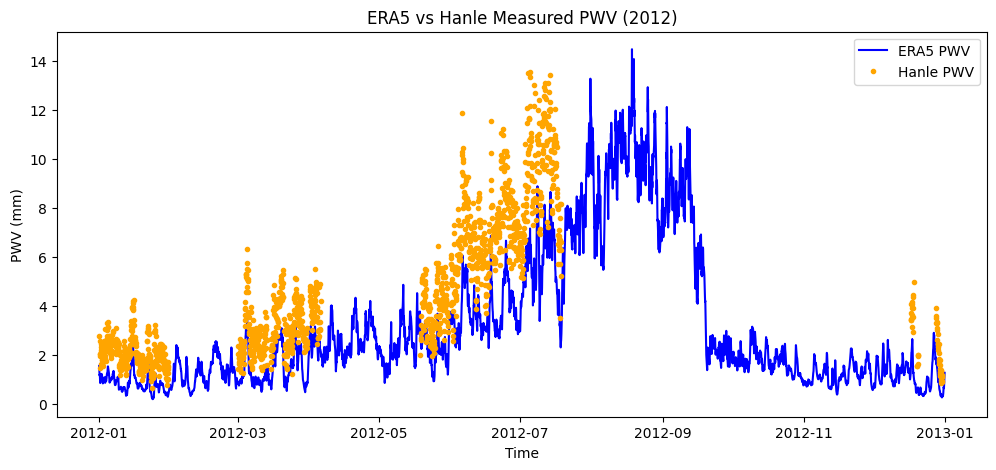

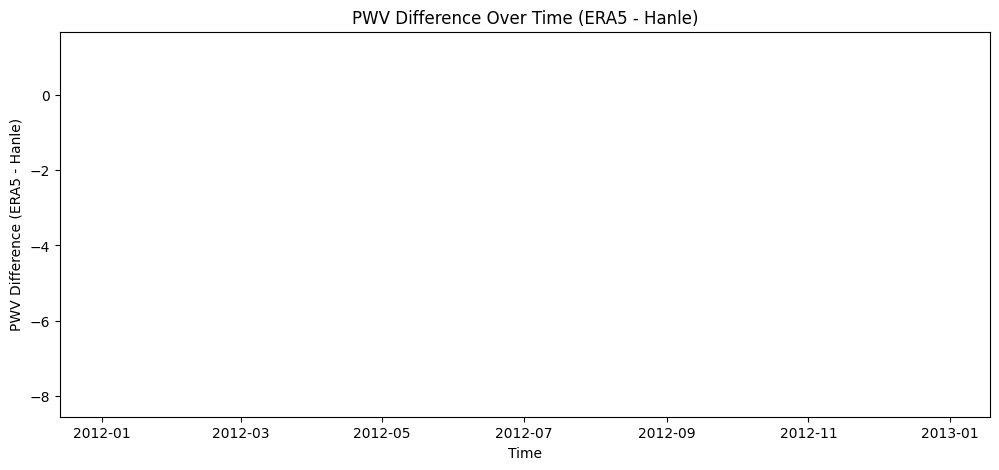

Number of ERA5 timestamps: 8784
Number of Hanle measurements in 2012: 1525
Mean difference: -2.1404923234314213
Max difference: 1.2130720138549806
Min difference: -8.086020240783691


In [63]:
# -------------------------------
# ERA5 vs Hanle PWV Comparison
# -------------------------------

import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# -------------------------------
# 1️⃣ Load ERA5 NetCDF
# -------------------------------
ds = xr.open_dataset("data_stream-oper_stepType-instant.nc")

# Extract PWV variable and time
pwv_era5 = ds["tcw"]
time_era5 = ds["valid_time"]

# Pick the closest pixel to Hanle (example indices; adjust as needed)
pwv_pixel = pwv_era5[:, 3, 2]  

# Create ERA5 DataFrame
era5_df = pd.DataFrame({
    "time": pd.to_datetime(time_era5.values).floor("h"),  # floor to hour
    "pwv_era5": pwv_pixel.values
})

# -------------------------------
# 2️⃣ Load Hanle data
# -------------------------------
hanle = pd.read_csv(
    "pwv_hanle.dat",
    sep=r"\s+",
    comment="#",
    names=["year","doy","hour","minute","second","pwv"]
)

# Convert to datetime
hanle["time"] = pd.to_datetime(
    hanle["year"].astype(str) + "-" + hanle["doy"].astype(str),
    format="%Y-%j"
) + pd.to_timedelta(hanle["hour"], unit="h")

# Create clean Hanle DataFrame
hanle_df = hanle[["time","pwv"]].rename(columns={"pwv":"pwv_hanle"})

# -------------------------------
# 3️⃣ Filter Hanle to 2012
# -------------------------------
hanle_df_2012 = hanle_df[hanle_df["time"].dt.year == 2012]

# -------------------------------
# 4️⃣ Reindex Hanle to ERA5 time grid (align timestamps)
# -------------------------------
hanle_df_2012 = hanle_df_2012.set_index("time")
hanle_df_2012 = hanle_df_2012.reindex(era5_df["time"]).reset_index().rename(columns={"index":"time"})

# -------------------------------
# 5️⃣ Merge ERA5 and Hanle
# -------------------------------
merged = pd.merge(
    era5_df,
    hanle_df_2012,
    on="time",
    how="left"  # keep all ERA5 times; missing Hanle becomes NaN
)

# -------------------------------
# 6️⃣ Plot ERA5 vs Hanle PWV
# -------------------------------
plt.figure(figsize=(12,5))
plt.plot(merged["time"], merged["pwv_era5"], label="ERA5 PWV", color="blue")
plt.plot(merged["time"], merged["pwv_hanle"], 'o', label="Hanle PWV", color="orange", markersize=3)
plt.xlabel("Time")
plt.ylabel("PWV (mm)")
plt.title("ERA5 vs Hanle Measured PWV (2012)")
plt.legend()
plt.show()

# -------------------------------
# 7️⃣ Calculate and plot difference
# -------------------------------
merged["difference"] = merged["pwv_era5"] - merged["pwv_hanle"]

plt.figure(figsize=(12,5))
plt.plot(merged["time"], merged["difference"], color="red")
plt.xlabel("Time")
plt.ylabel("PWV Difference (ERA5 - Hanle)")
plt.title("PWV Difference Over Time (ERA5 - Hanle)")
plt.show()

# -------------------------------
# 8️⃣ Optional: summary stats
# -------------------------------
print("Number of ERA5 timestamps:", len(merged))
print("Number of Hanle measurements in 2012:", merged["pwv_hanle"].notna().sum())
print("Mean difference:", merged["difference"].mean(skipna=True))
print("Max difference:", merged["difference"].max())
print("Min difference:", merged["difference"].min())

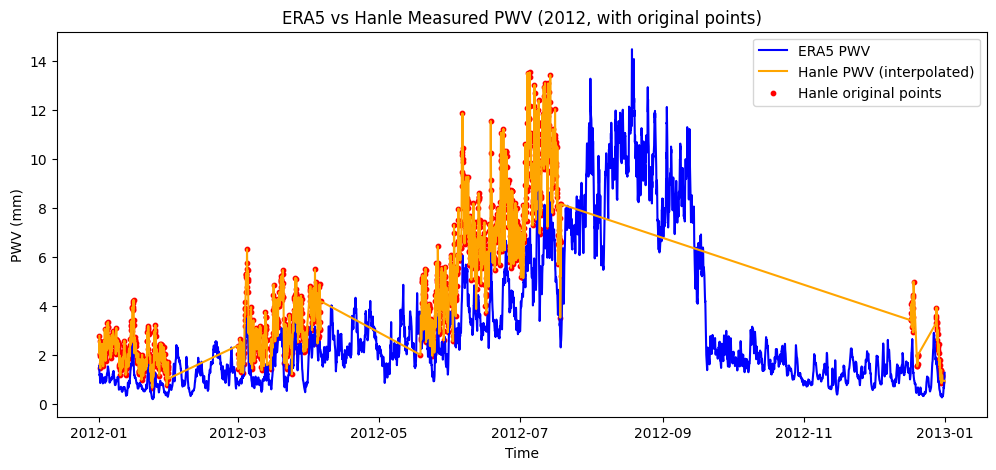

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(merged_interp["time"], merged_interp["pwv_era5"], label="ERA5 PWV", color="blue")
plt.plot(merged_interp["time"], merged_interp["pwv_hanle"], label="Hanle PWV (interpolated)", color="orange")
plt.scatter(hanle_df_2012["time"], hanle_df_2012["pwv_hanle"], color="red", s=10, label="Hanle original points")
plt.xlabel("Time")
plt.ylabel("PWV (mm)")
plt.title("ERA5 vs Hanle Measured PWV (2012, with original points)")
plt.legend()
plt.show()

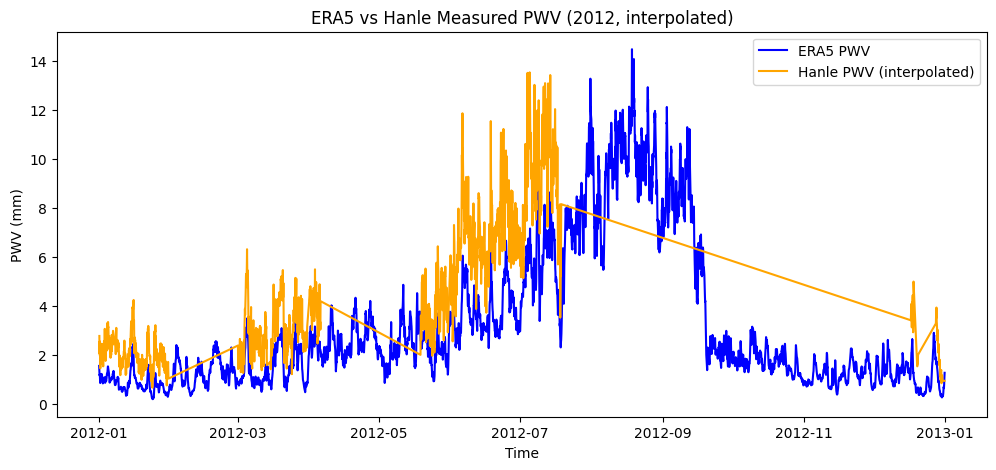

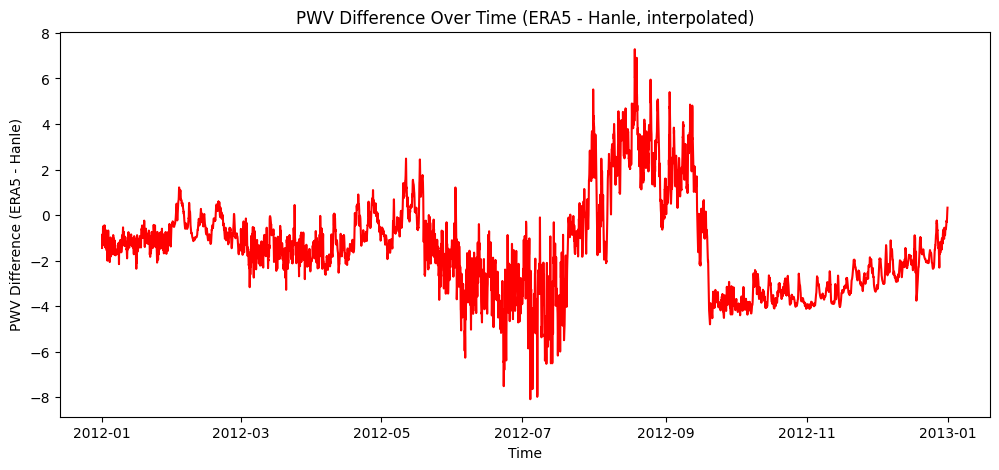

In [65]:
# -------------------------------
# ERA5 vs Hanle PWV with interpolated Hanle
# -------------------------------

import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# -------------------------------
# 1️⃣ Load ERA5 NetCDF
# -------------------------------
ds = xr.open_dataset("data_stream-oper_stepType-instant.nc")
pwv_era5 = ds["tcw"]
time_era5 = ds["valid_time"]

# Closest Hanle pixel (adjust indices if needed)
pwv_pixel = pwv_era5[:, 3, 2]

era5_df = pd.DataFrame({
    "time": pd.to_datetime(time_era5.values).floor("h"),
    "pwv_era5": pwv_pixel.values
})

# -------------------------------
# 2️⃣ Load Hanle data
# -------------------------------
hanle = pd.read_csv(
    "pwv_hanle.dat",
    sep=r"\s+",
    comment="#",
    names=["year","doy","hour","minute","second","pwv"]
)

# Convert to datetime
hanle["time"] = pd.to_datetime(
    hanle["year"].astype(str) + "-" + hanle["doy"].astype(str),
    format="%Y-%j"
) + pd.to_timedelta(hanle["hour"], unit="h")

# Keep only relevant columns
hanle_df = hanle[["time","pwv"]].rename(columns={"pwv":"pwv_hanle"})

# -------------------------------
# 3️⃣ Filter to 2012
# -------------------------------
hanle_df_2012 = hanle_df[hanle_df["time"].dt.year == 2012]

# -------------------------------
# 4️⃣ Interpolate Hanle to ERA5 hourly grid
# -------------------------------
hanle_interp = hanle_df_2012.set_index("time").reindex(era5_df["time"]).interpolate("time").reset_index()
hanle_interp.rename(columns={"index":"time"}, inplace=True)

# -------------------------------
# 5️⃣ Merge ERA5 and interpolated Hanle
# -------------------------------
merged_interp = pd.merge(era5_df, hanle_interp, on="time", how="left")

# -------------------------------
# 6️⃣ Plot ERA5 vs interpolated Hanle
# -------------------------------
plt.figure(figsize=(12,5))
plt.plot(merged_interp["time"], merged_interp["pwv_era5"], label="ERA5 PWV", color="blue")
plt.plot(merged_interp["time"], merged_interp["pwv_hanle"], label="Hanle PWV (interpolated)", color="orange")
plt.xlabel("Time")
plt.ylabel("PWV (mm)")
plt.title("ERA5 vs Hanle Measured PWV (2012, interpolated)")
plt.legend()
plt.show()

# -------------------------------
# 7️⃣ Plot difference
# -------------------------------
merged_interp["difference"] = merged_interp["pwv_era5"] - merged_interp["pwv_hanle"]

plt.figure(figsize=(12,5))
plt.plot(merged_interp["time"], merged_interp["difference"], color="red")
plt.xlabel("Time")
plt.ylabel("PWV Difference (ERA5 - Hanle)")
plt.title("PWV Difference Over Time (ERA5 - Hanle, interpolated)")
plt.show()